# UWB Distance Estimation (Regression)

This notebook tunes several regression algorithms to estimate the distances of the two dominant shortest paths and compares their performance in the full LOS/NLOS pipeline.

**Objectives:**
1. Train multi-output regressors to predict continuous distance measurements: `[RANGE, RANGE2]`.
2. Tune hyperparameters via cross-validated randomized search.
3. Evaluate model performance using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and $R^2$ Score to determine the best candidate for the end-to-end pipeline.


In [18]:
import warnings
warnings.filterwarnings('ignore')


import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load regression data generated from preprocessing pipeline.
data = np.load('multi_regression_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

model_metrics = {}
predictions = {}
cv_tables = {}
cv_fold_results = {}


def compute_metrics(y_true, y_pred):
    return {
        'path_1_rmse': float(np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))),
        'path_1_mae': float(mean_absolute_error(y_true[:, 0], y_pred[:, 0])),
        'path_1_r2': float(r2_score(y_true[:, 0], y_pred[:, 0])),
        'path_2_rmse': float(np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))),
        'path_2_mae': float(mean_absolute_error(y_true[:, 1], y_pred[:, 1])),
        'path_2_r2': float(r2_score(y_true[:, 1], y_pred[:, 1])),
    }


def print_metrics(model_name, metrics):
    print(f"{model_name} Performance:")
    print(
        f"Path 1 - RMSE: {metrics['path_1_rmse']:.4f} | "
        f"MAE: {metrics['path_1_mae']:.4f} | R2: {metrics['path_1_r2']:.4f}"
    )
    print(
        f"Path 2 - RMSE: {metrics['path_2_rmse']:.4f} | "
        f"MAE: {metrics['path_2_mae']:.4f} | R2: {metrics['path_2_r2']:.4f}"
    )


def top_cv_results(search):
    results = pd.DataFrame(search.cv_results_).copy()
    param_cols = sorted(col for col in results.columns if col.startswith('param_'))
    summary = results[['rank_test_score', 'mean_test_score', 'std_test_score', *param_cols]].copy()
    summary = summary.sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).head(5)
    summary['cv_rmse_proxy'] = np.sqrt(-summary['mean_test_score'])
    summary = summary.rename(
        columns={
            'rank_test_score': 'rank',
            'std_test_score': 'cv_score_std',
            **{col: col.replace('param_estimator__', '') for col in param_cols},
        }
    )
    cols = ['rank', 'cv_rmse_proxy', 'cv_score_std'] + [col.replace('param_estimator__', '') for col in param_cols]
    return summary[cols].reset_index(drop=True)


def evaluate_cv_folds(estimator, X, y, n_splits=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        model = clone(estimator)
        model.fit(X[train_idx], y[train_idx])
        fold_pred = model.predict(X[val_idx])
        fold_metrics = compute_metrics(y[val_idx], fold_pred)
        rows.append({'fold': fold_idx, **fold_metrics})
    return pd.DataFrame(rows)


X_train shape: (33600, 104)
y_train shape: (33600, 2)
X_test shape: (8400, 104)
y_test shape: (8400, 2)


## 1. Random Forest Regressor

Randomized search is used to tune the Random Forest hyperparameters before evaluating the best multi-output model on the held-out test set.


In [19]:
rf_param_distributions = {
    'estimator__n_estimators': [100, 200, 300, 400],
    'estimator__max_depth': [10, 15, 20, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)),
    param_distributions=rf_param_distributions,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print('Running RandomizedSearchCV for Random Forest...')
rf_search.fit(X_train, y_train)

rf = rf_search.best_estimator_
rf_preds = rf.predict(X_test)
rf_metrics = compute_metrics(y_test, rf_preds)
model_metrics['Random Forest'] = rf_metrics
predictions['Random Forest'] = rf_preds
cv_tables['Random Forest'] = top_cv_results(rf_search)
cv_fold_results['Random Forest'] = evaluate_cv_folds(rf, X_train, y_train)

rf_rmse1 = rf_metrics['path_1_rmse']
rf_mae1 = rf_metrics['path_1_mae']
rf_r21 = rf_metrics['path_1_r2']
rf_rmse2 = rf_metrics['path_2_rmse']
rf_mae2 = rf_metrics['path_2_mae']
rf_r22 = rf_metrics['path_2_r2']

print('Best Random Forest parameters:')
for key, value in rf_search.best_params_.items():
    print(f"  {key.replace('estimator__', '')}: {value}")
print()
print_metrics('Random Forest', rf_metrics)


Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest parameters:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: None

Random Forest Performance:
Path 1 - RMSE: 1.1309 | MAE: 0.8512 | R2: 0.7673
Path 2 - RMSE: 1.3714 | MAE: 1.0101 | R2: 0.8049


In [20]:
print('Top 5 Random Forest search results:')
print(cv_tables['Random Forest'].to_string(index=False))


Top 5 Random Forest search results:
 rank  cv_rmse_proxy  cv_score_std max_depth max_features  min_samples_leaf  min_samples_split  n_estimators
    1       1.277421      0.052669      None          0.5                 2                  5           300
    2       1.281627      0.052674        15          0.5                 2                  2           400
    3       1.282053      0.052101        15          0.5                 2                  5           400
    4       1.283936      0.048457      None          0.5                 4                  5           100
    5       1.286172      0.050354        15          0.5                 1                  2           100


## 2. HistGradientBoosting Regressor

HistGradientBoosting is tuned over learning rate, tree depth, iteration count, and regularization settings to improve generalization on the tabular CIR features.


In [21]:
hgb_param_distributions = {
    'estimator__max_iter': [100, 200, 300, 400],
    'estimator__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'estimator__max_depth': [5, 8, 10, 12, None],
    'estimator__min_samples_leaf': [10, 20, 30, 40],
    'estimator__l2_regularization': [0.0, 0.01, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42)),
    param_distributions=hgb_param_distributions,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print('Running RandomizedSearchCV for HistGradientBoosting...')
hgb_search.fit(X_train, y_train)

hgb = hgb_search.best_estimator_
hgb_preds = hgb.predict(X_test)
hgb_metrics = compute_metrics(y_test, hgb_preds)
model_metrics['HistGradientBoosting'] = hgb_metrics
predictions['HistGradientBoosting'] = hgb_preds
cv_tables['HistGradientBoosting'] = top_cv_results(hgb_search)
cv_fold_results['HistGradientBoosting'] = evaluate_cv_folds(hgb, X_train, y_train)

hgb_rmse1 = hgb_metrics['path_1_rmse']
hgb_mae1 = hgb_metrics['path_1_mae']
hgb_r21 = hgb_metrics['path_1_r2']
hgb_rmse2 = hgb_metrics['path_2_rmse']
hgb_mae2 = hgb_metrics['path_2_mae']
hgb_r22 = hgb_metrics['path_2_r2']

print('Best HistGradientBoosting parameters:')
for key, value in hgb_search.best_params_.items():
    print(f"  {key.replace('estimator__', '')}: {value}")
print()
print_metrics('HistGradientBoosting', hgb_metrics)


Running RandomizedSearchCV for HistGradientBoosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best HistGradientBoosting parameters:
  min_samples_leaf: 40
  max_iter: 400
  max_depth: None
  learning_rate: 0.05
  l2_regularization: 0.0

HistGradientBoosting Performance:
Path 1 - RMSE: 1.1384 | MAE: 0.8557 | R2: 0.7643
Path 2 - RMSE: 1.3505 | MAE: 1.0019 | R2: 0.8108


In [22]:
print('Top 5 HistGradientBoosting search results:')
print(cv_tables['HistGradientBoosting'].to_string(index=False))


Top 5 HistGradientBoosting search results:
 rank  cv_rmse_proxy  cv_score_std  l2_regularization  learning_rate max_depth  max_iter  min_samples_leaf
    1       1.263821      0.057667               0.00           0.05      None       400                40
    2       1.265616      0.056106               0.01           0.03      None       400                20
    3       1.265679      0.051382               0.01           0.05        10       400                30
    4       1.268030      0.057268               1.00           0.05        10       200                40
    5       1.268239      0.054214               0.01           0.10      None       200                30


## 3. Multi-layer Perceptron (MLP) Regressor

The MLP regressor is tuned across architecture size, regularization, activation, and optimizer learning rate to capture non-linear feature interactions.


In [23]:
mlp_param_distributions = {
    'estimator__hidden_layer_sizes': [(64, 32), (128, 64), (256, 128), (128, 64, 32)],
    'estimator__activation': ['relu', 'tanh'],
    'estimator__alpha': [0.0001, 0.001, 0.01],
    'estimator__learning_rate_init': [0.001, 0.003, 0.005, 0.01],
}

mlp_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(
        MLPRegressor(
            solver='adam',
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            max_iter=500,
            random_state=42,
        )
    ),
    param_distributions=mlp_param_distributions,
    n_iter=15,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print('Running RandomizedSearchCV for MLP...')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    mlp_search.fit(X_train, y_train)

mlp = mlp_search.best_estimator_
mlp_preds = mlp.predict(X_test)
mlp_metrics = compute_metrics(y_test, mlp_preds)
model_metrics['MLP'] = mlp_metrics
predictions['MLP'] = mlp_preds
cv_tables['MLP'] = top_cv_results(mlp_search)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    cv_fold_results['MLP'] = evaluate_cv_folds(mlp, X_train, y_train)

mlp_rmse1 = mlp_metrics['path_1_rmse']
mlp_mae1 = mlp_metrics['path_1_mae']
mlp_r21 = mlp_metrics['path_1_r2']
mlp_rmse2 = mlp_metrics['path_2_rmse']
mlp_mae2 = mlp_metrics['path_2_mae']
mlp_r22 = mlp_metrics['path_2_r2']

print('Best MLP parameters:')
for key, value in mlp_search.best_params_.items():
    print(f"  {key.replace('estimator__', '')}: {value}")
print()
print_metrics('MLPRegressor', mlp_metrics)


Running RandomizedSearchCV for MLP...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best MLP parameters:
  learning_rate_init: 0.003
  hidden_layer_sizes: (128, 64, 32)
  alpha: 0.001
  activation: tanh

MLPRegressor Performance:
Path 1 - RMSE: 1.1261 | MAE: 0.8426 | R2: 0.7693
Path 2 - RMSE: 1.4218 | MAE: 1.0484 | R2: 0.7903


In [24]:
print('Top 5 MLP search results:')
print(cv_tables['MLP'].to_string(index=False))


Top 5 MLP search results:
 rank  cv_rmse_proxy  cv_score_std activation  alpha hidden_layer_sizes  learning_rate_init
    1       1.331099      0.064245       tanh 0.0010      (128, 64, 32)               0.003
    2       1.331957      0.038345       tanh 0.0100      (128, 64, 32)               0.005
    3       1.338328      0.059398       tanh 0.0010      (128, 64, 32)               0.010
    4       1.340079      0.056563       relu 0.0010      (128, 64, 32)               0.005
    5       1.341237      0.052173       relu 0.0001           (64, 32)               0.001


## 4. Stacking Regressor

A stacking ensemble combines the tuned Random Forest and HistGradientBoosting models as level-0 base regressors. A Ridge meta-regressor learns to optimally blend their out-of-fold predictions, capturing the complementary strengths of each base model without requiring a separate hyperparameter search.

In [25]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
# Build base estimators using best hyperparameters from the tuned searches
rf_best_params = {k.replace('estimator__', ''): v for k, v in rf_search.best_params_.items()}
hgb_best_params = {k.replace('estimator__', ''): v for k, v in hgb_search.best_params_.items()}

stack_base_estimators = [
    ('rf', RandomForestRegressor(**rf_best_params, random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingRegressor(**hgb_best_params, random_state=42)),
]

stack = MultiOutputRegressor(
    StackingRegressor(
        estimators=stack_base_estimators,
        final_estimator=Ridge(),
        cv=3,
        n_jobs=-1,
        passthrough=False,
    )
)

print('Training Stacking Regressor (RF + HGB -> Ridge)...')
stack.fit(X_train, y_train)

stack_preds = stack.predict(X_test)
stack_metrics = compute_metrics(y_test, stack_preds)
model_metrics['Stacking'] = stack_metrics
predictions['Stacking'] = stack_preds
cv_fold_results['Stacking'] = evaluate_cv_folds(stack, X_train, y_train)

stack_rmse1 = stack_metrics['path_1_rmse']
stack_mae1 = stack_metrics['path_1_mae']
stack_r21 = stack_metrics['path_1_r2']
stack_rmse2 = stack_metrics['path_2_rmse']
stack_mae2 = stack_metrics['path_2_mae']
stack_r22 = stack_metrics['path_2_r2']

print_metrics('Stacking (RF + HGB)', stack_metrics)


Training Stacking Regressor (RF + HGB -> Ridge)...
Stacking (RF + HGB) Performance:
Path 1 - RMSE: 1.1191 | MAE: 0.8330 | R2: 0.7722
Path 2 - RMSE: 1.3416 | MAE: 0.9868 | R2: 0.8133


## 5. Model Evaluation & Diagnostics

To rigorously evaluate the regressors, we analyze their performance across multiple dimensions: overall metric comparison, cross-validation stability, scatter distribution against ground-truth, residual structures, and error bias. These diagnostics help identify models that not only perform well on average but are robust against systematic under/over-estimation.

## Visualization: Model Comparison by Metric

The grouped charts below compare the tuned models on the held-out test set. Error bars show the standard deviation across 3 cross-validation folds for the tuned estimator.


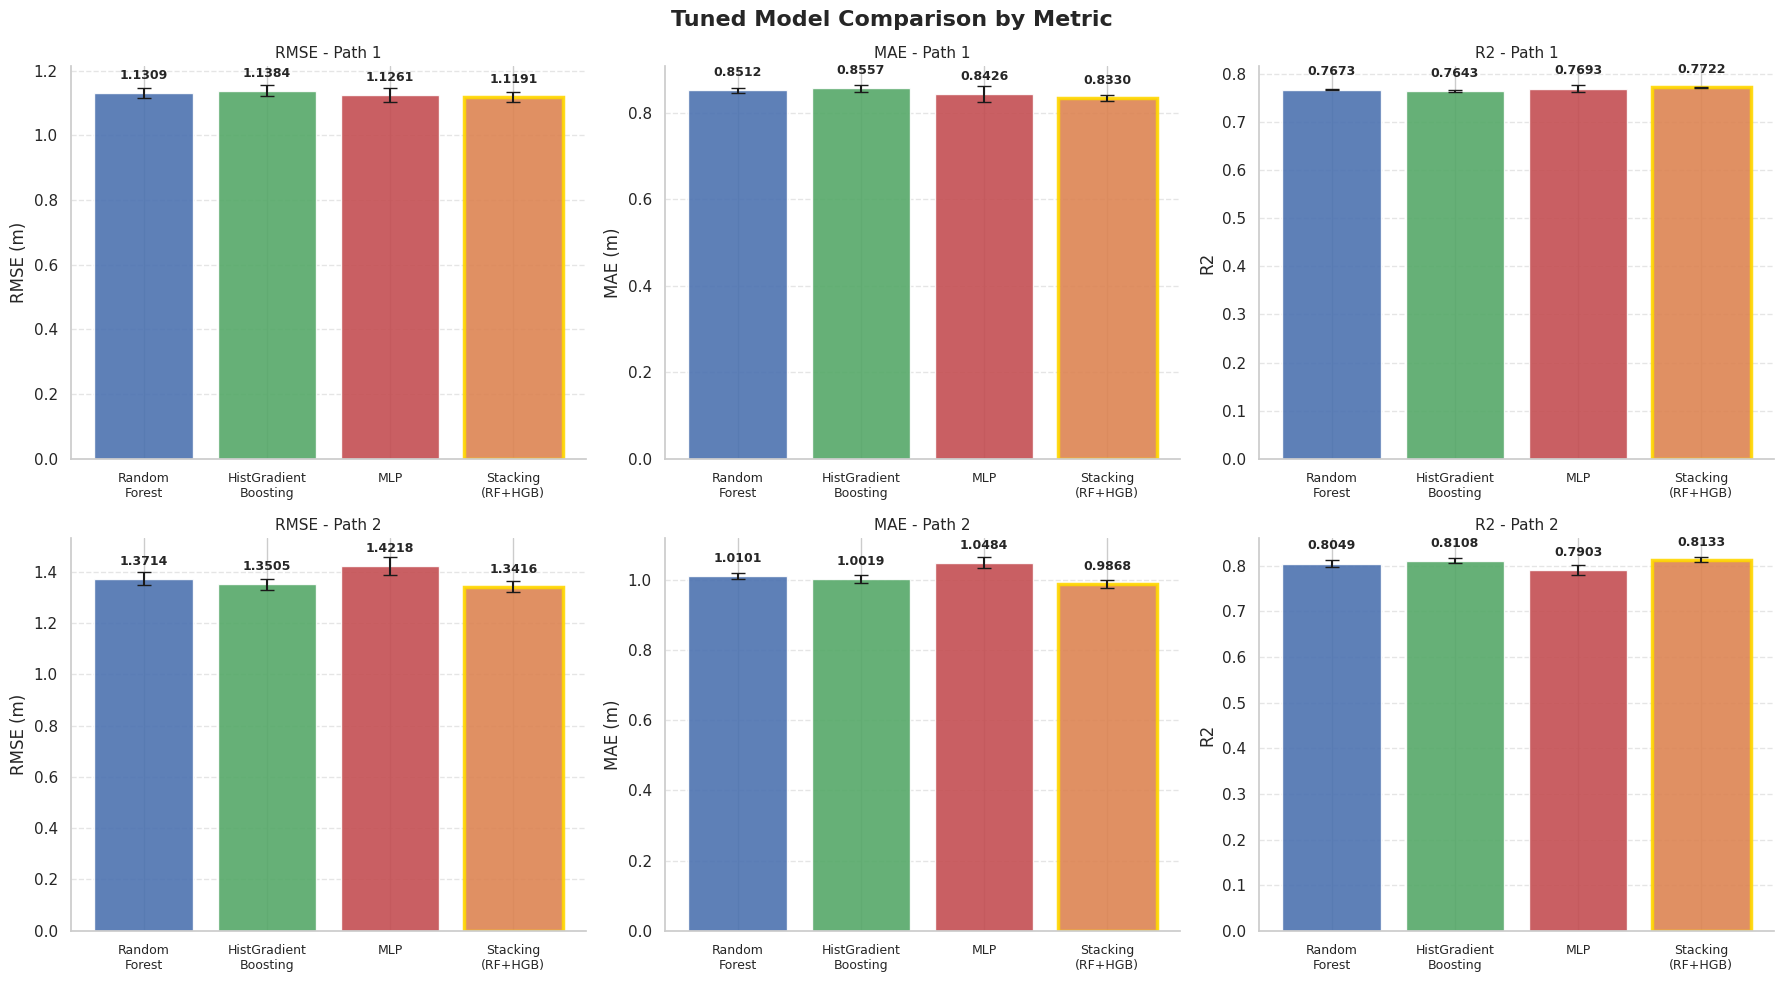

Gold outline marks the best test-set value for each metric. Error bars show CV standard deviation.


In [26]:
model_order = ['Random Forest', 'HistGradientBoosting', 'MLP', 'Stacking']
display_names = ['Random\nForest', 'HistGradient\nBoosting', 'MLP', 'Stacking\n(RF+HGB)']
color_map = {
    'Random Forest': '#4C72B0',
    'HistGradientBoosting': '#55A868',
    'MLP': '#C44E52',
    'Stacking': '#DD8452',
}
metric_config = {
    'RMSE': {'suffix': 'rmse', 'ylabel': 'RMSE (m)', 'lower_is_better': True},
    'MAE': {'suffix': 'mae', 'ylabel': 'MAE (m)', 'lower_is_better': True},
    'R2': {'suffix': 'r2', 'ylabel': 'R2', 'lower_is_better': False},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tuned Model Comparison by Metric', fontsize=16, fontweight='bold')
x = np.arange(len(model_order))

for col_idx, (metric_name, config) in enumerate(metric_config.items()):
    for row_idx, path_num in enumerate([1, 2]):
        key = f'path_{path_num}_{config["suffix"]}'
        ax = axes[row_idx, col_idx]
        values = [model_metrics[model][key] for model in model_order]
        errors = [cv_fold_results[model][key].std(ddof=1) for model in model_order]
        colors = [color_map[model] for model in model_order]
        bars = ax.bar(x, values, color=colors, yerr=errors, capsize=5, alpha=0.9, edgecolor='white')

        best_idx = int(np.argmin(values) if config['lower_is_better'] else np.argmax(values))
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)

        value_pad = max(abs(v) for v in values) * 0.03 if max(abs(v) for v in values) > 0 else 0.02
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + value_pad,
                f'{value:.4f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
            )

        ax.set_title(f'{metric_name} - Path {path_num}', fontsize=11)
        ax.set_ylabel(config['ylabel'])
        ax.set_xticks(x)
        ax.set_xticklabels(display_names, fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print('Gold outline marks the best test-set value for each metric. Error bars show CV standard deviation.')


## Visualization: Cross-Validation Stability

Box plots summarize the fold-to-fold RMSE variation for the tuned models on Path 1 and Path 2. Narrower boxes indicate more stable validation performance.


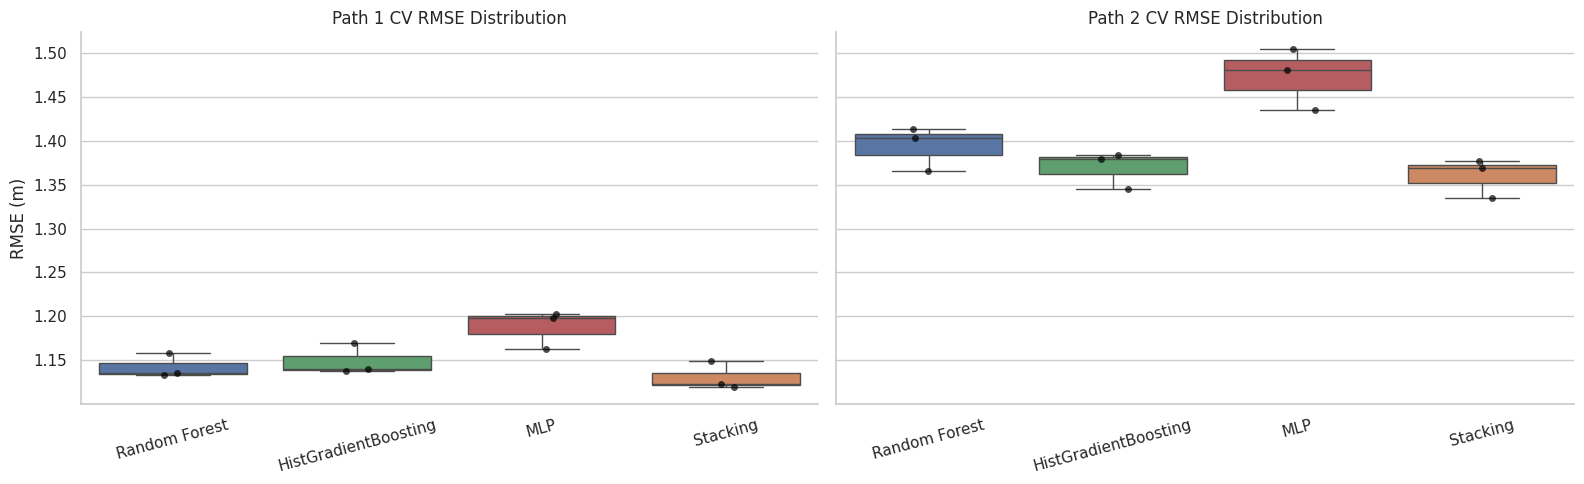

In [27]:
cv_rows = []
for model_name, fold_df in cv_fold_results.items():
    for _, row in fold_df.iterrows():
        cv_rows.append({'Model': model_name, 'Path': 'Path 1', 'Fold': int(row['fold']), 'RMSE': row['path_1_rmse']})
        cv_rows.append({'Model': model_name, 'Path': 'Path 2', 'Fold': int(row['fold']), 'RMSE': row['path_2_rmse']})

cv_long_df = pd.DataFrame(cv_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, path_label in zip(axes, ['Path 1', 'Path 2']):
    subset = cv_long_df[cv_long_df['Path'] == path_label]
    sns.boxplot(data=subset, x='Model', y='RMSE', ax=ax, palette=[color_map[m] for m in model_order])
    sns.stripplot(data=subset, x='Model', y='RMSE', ax=ax, color='black', size=5, alpha=0.7)
    ax.set_title(f'{path_label} CV RMSE Distribution')
    ax.set_xlabel('')
    ax.set_ylabel('RMSE (m)')
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Save Best Regression Model

The model with the lowest average RMSE across both paths is selected and saved to disk so the end-to-end pipeline notebook can load it directly without retraining.

> **Note on the NLOS feature:** The last column of `X_train` / `X_test` is the **ground-truth NLOS label** appended during preprocessing. This is correct for supervised training because the regressor learns how the true channel condition affects path distance. At inference time (see `pipeline.ipynb`), this column is replaced by the classifier's predicted NLOS label.

In [28]:
candidate_models = {
    'Random Forest': rf,
    'HistGradientBoosting': hgb,
    'MLP': mlp,
    'Stacking': stack,
}

best_model_name = min(
    model_metrics,
    key=lambda m: (model_metrics[m]['path_1_rmse'] + model_metrics[m]['path_2_rmse']) / 2,
)
best_model = candidate_models[best_model_name]

joblib.dump(best_model, 'regressor.pkl')
print(f'Best model: {best_model_name}')
print(
    f"  Path 1 RMSE: {model_metrics[best_model_name]['path_1_rmse']:.4f} | "
    f"Path 2 RMSE: {model_metrics[best_model_name]['path_2_rmse']:.4f}"
)
print('Saved to regressor.pkl')


Best model: Stacking
  Path 1 RMSE: 1.1191 | Path 2 RMSE: 1.3416
Saved to regressor.pkl


## Visualization: True vs Predicted Distances

Scatter plots compare ground-truth path distances with each model's predictions. Points closer to the diagonal indicate more accurate estimates.


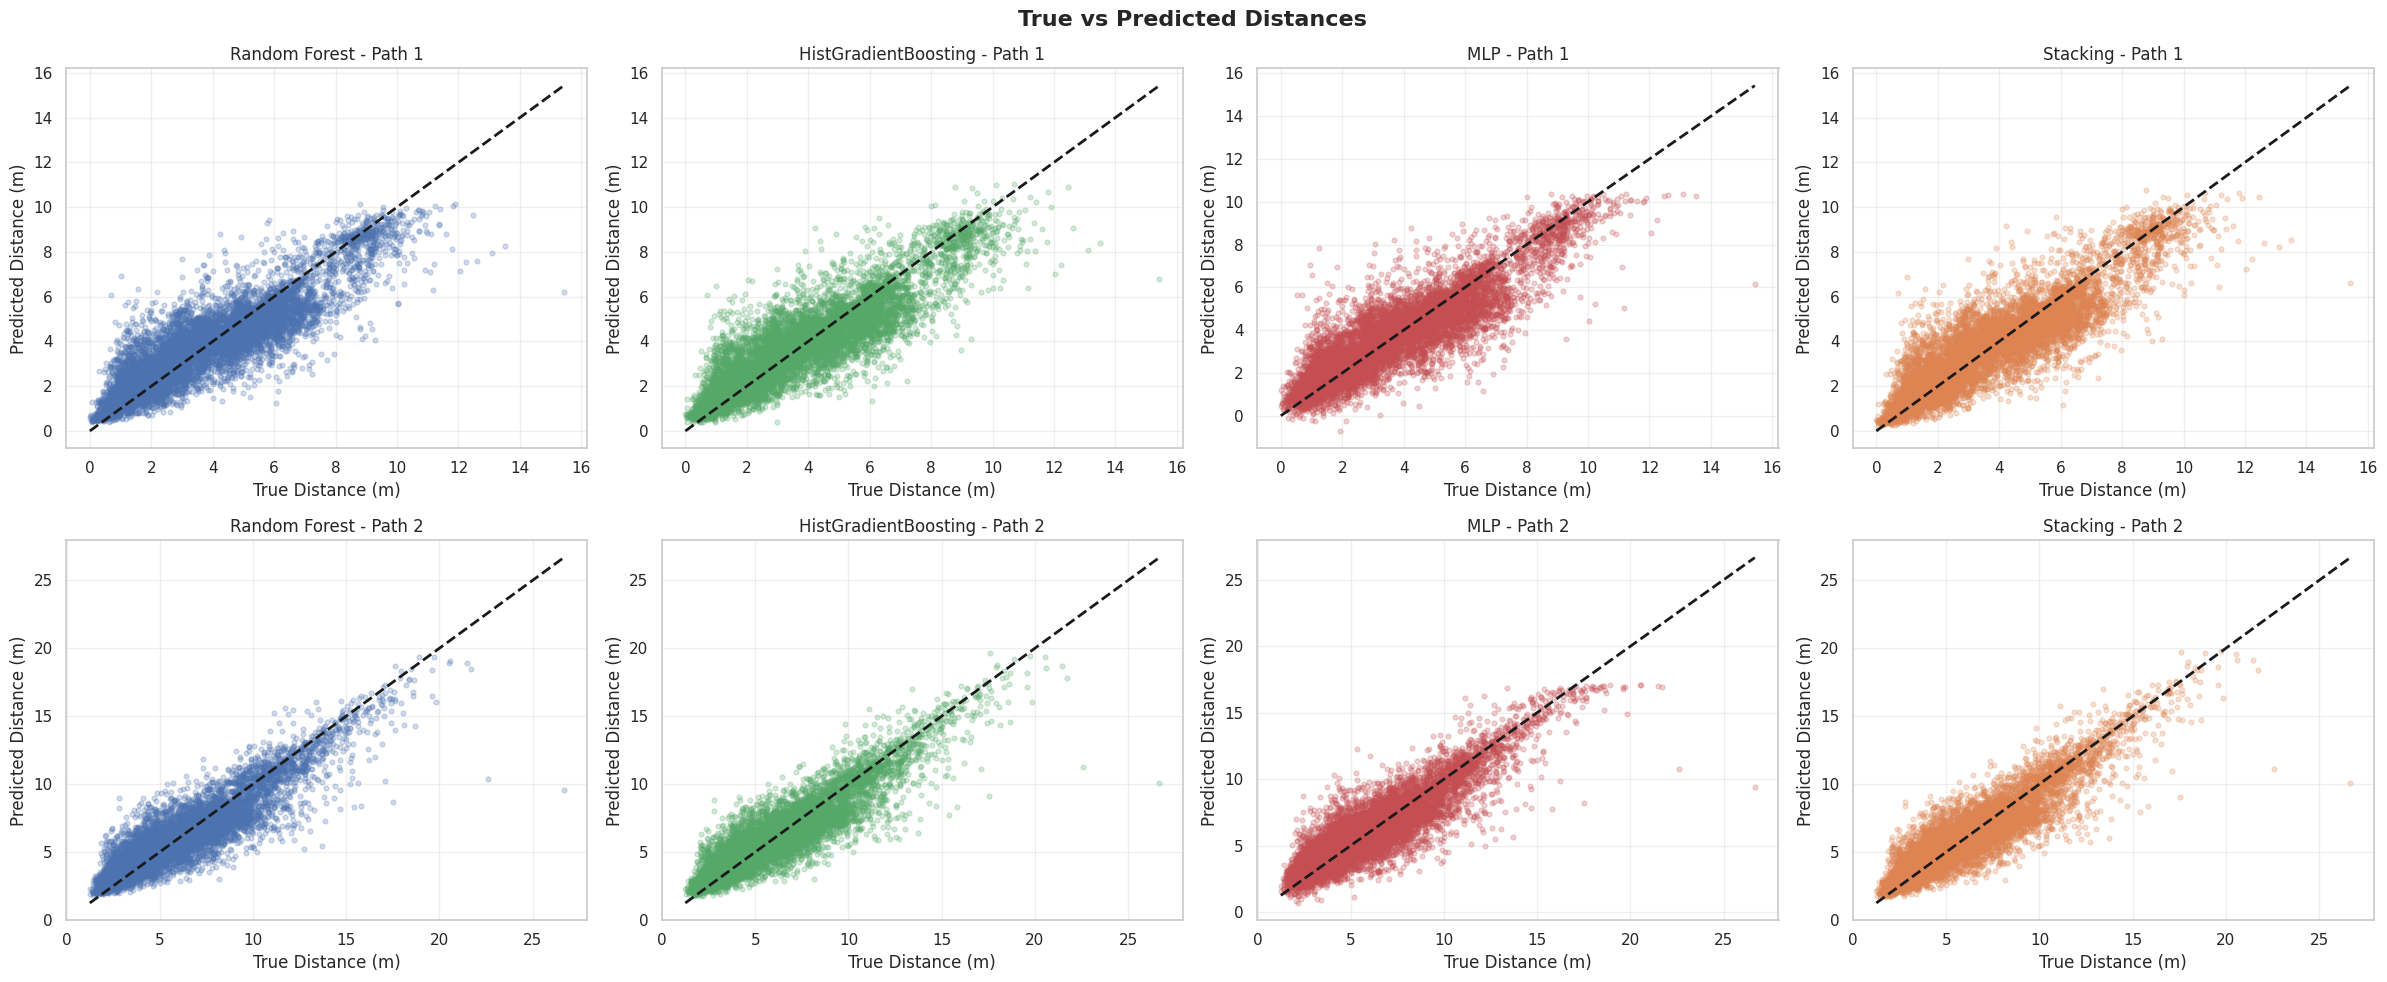

In [29]:
models = ['Random Forest', 'HistGradientBoosting', 'MLP', 'Stacking']
preds = [rf_preds, hgb_preds, mlp_preds, stack_preds]
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('True vs Predicted Distances', fontsize=16, fontweight='bold')

for idx, model_name in enumerate(models):
    axes[0, idx].scatter(y_test[:, 0], preds[idx][:, 0], alpha=0.25, color=colors[idx], s=12)
    axes[0, idx].plot([y_test[:, 0].min(), y_test[:, 0].max()], [y_test[:, 0].min(), y_test[:, 0].max()], 'k--', lw=2)
    axes[0, idx].set_title(f'{model_name} - Path 1')
    axes[0, idx].set_xlabel('True Distance (m)')
    axes[0, idx].set_ylabel('Predicted Distance (m)')
    axes[0, idx].grid(True, alpha=0.3)

    axes[1, idx].scatter(y_test[:, 1], preds[idx][:, 1], alpha=0.25, color=colors[idx], s=12)
    axes[1, idx].plot([y_test[:, 1].min(), y_test[:, 1].max()], [y_test[:, 1].min(), y_test[:, 1].max()], 'k--', lw=2)
    axes[1, idx].set_title(f'{model_name} - Path 2')
    axes[1, idx].set_xlabel('True Distance (m)')
    axes[1, idx].set_ylabel('Predicted Distance (m)')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization: Residual Plots

Residual plots show prediction error against the predicted value. Good residual behavior is centered around zero without strong systematic structure.


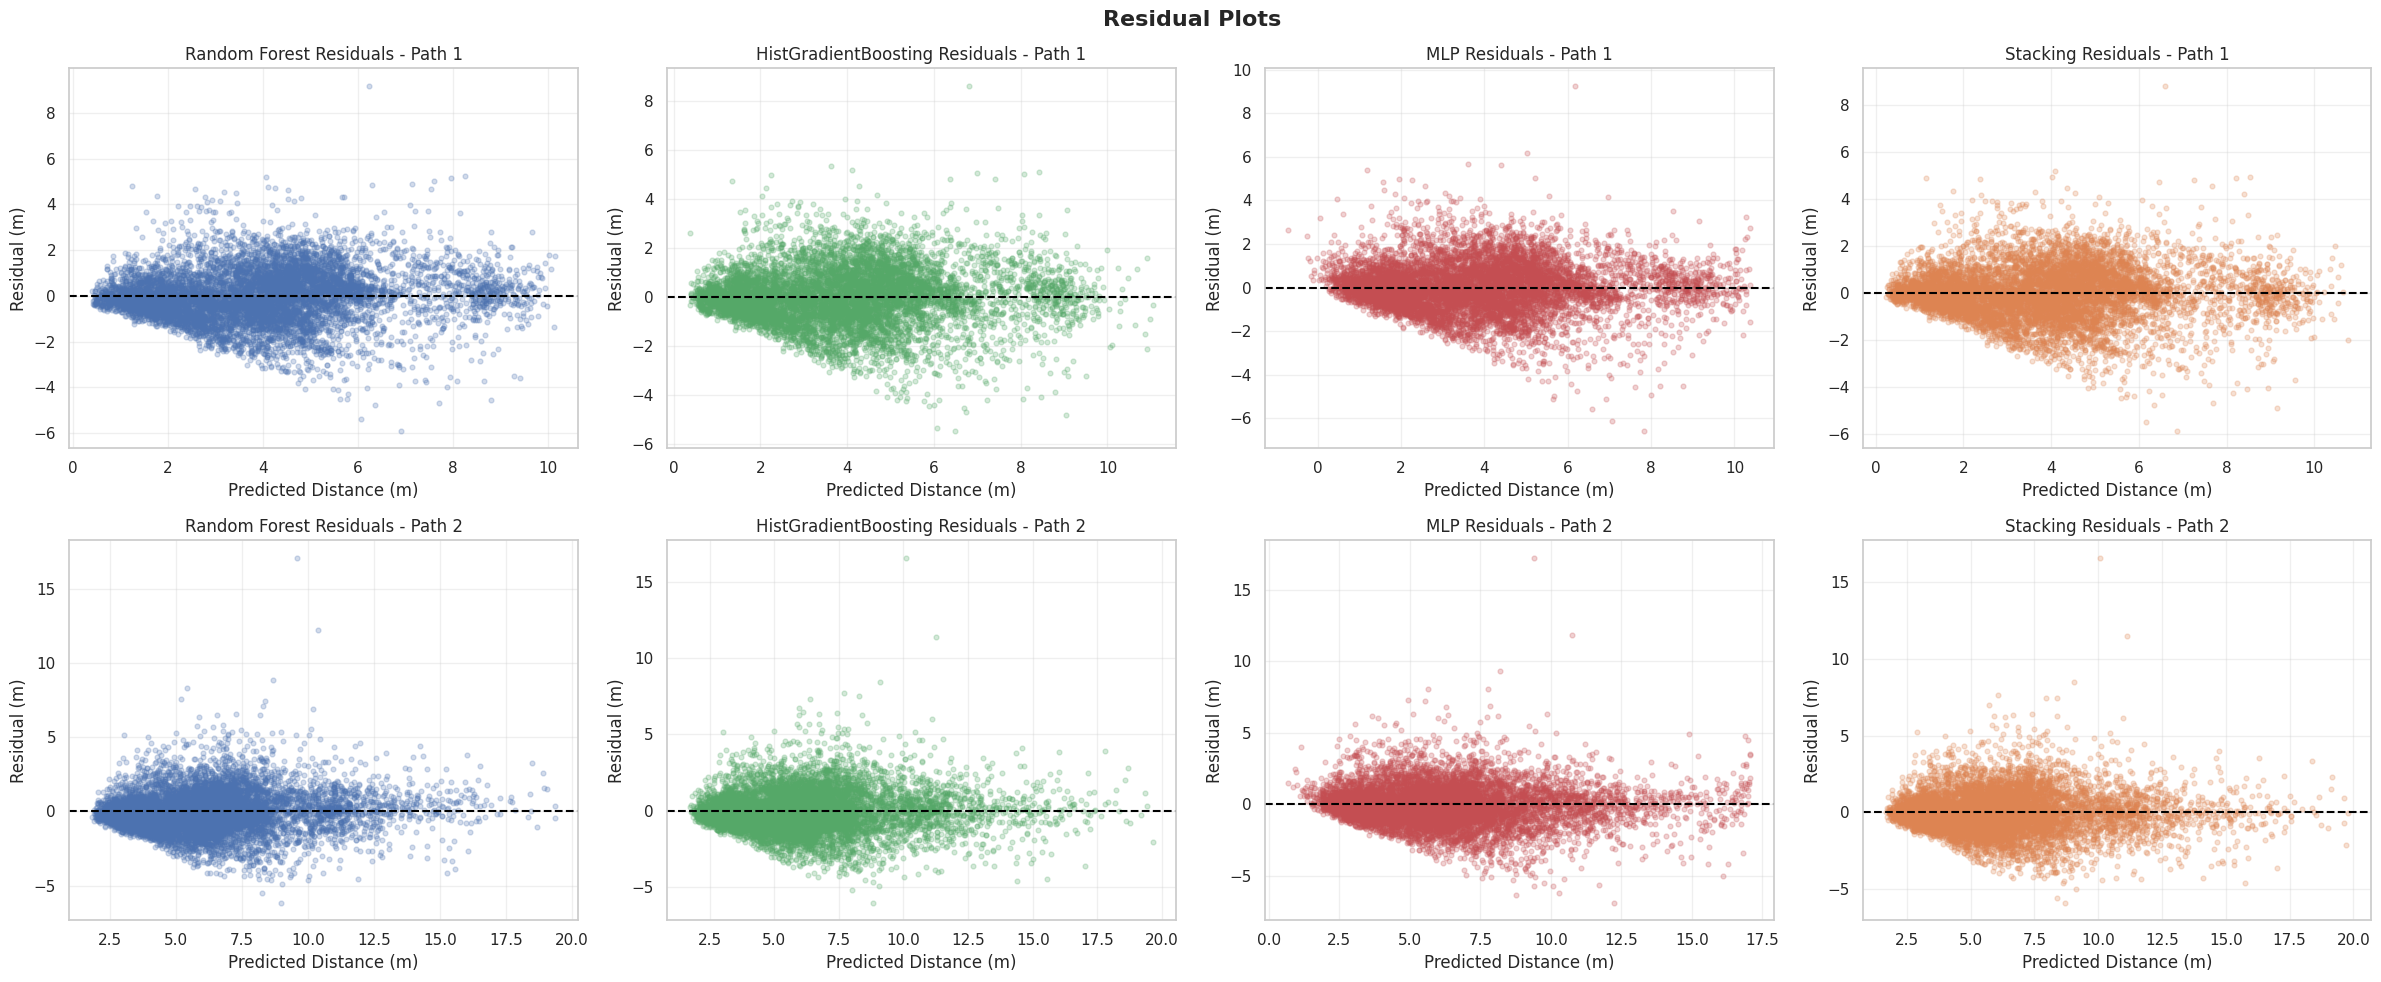

In [30]:
rf_res_p1 = y_test[:, 0] - rf_preds[:, 0]
rf_res_p2 = y_test[:, 1] - rf_preds[:, 1]
hgb_res_p1 = y_test[:, 0] - hgb_preds[:, 0]
hgb_res_p2 = y_test[:, 1] - hgb_preds[:, 1]
mlp_res_p1 = y_test[:, 0] - mlp_preds[:, 0]
mlp_res_p2 = y_test[:, 1] - mlp_preds[:, 1]
stack_res_p1 = y_test[:, 0] - stack_preds[:, 0]
stack_res_p2 = y_test[:, 1] - stack_preds[:, 1]

residual_sets = [
    (rf_res_p1, rf_res_p2),
    (hgb_res_p1, hgb_res_p2),
    (mlp_res_p1, mlp_res_p2),
    (stack_res_p1, stack_res_p2),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Residual Plots', fontsize=16, fontweight='bold')

for idx, model_name in enumerate(models):
    axes[0, idx].scatter(preds[idx][:, 0], residual_sets[idx][0], alpha=0.25, color=colors[idx], s=12)
    axes[0, idx].axhline(y=0, color='black', linestyle='--', lw=1.5)
    axes[0, idx].set_title(f'{model_name} Residuals - Path 1')
    axes[0, idx].set_xlabel('Predicted Distance (m)')
    axes[0, idx].set_ylabel('Residual (m)')
    axes[0, idx].grid(True, alpha=0.3)

    axes[1, idx].scatter(preds[idx][:, 1], residual_sets[idx][1], alpha=0.25, color=colors[idx], s=12)
    axes[1, idx].axhline(y=0, color='black', linestyle='--', lw=1.5)
    axes[1, idx].set_title(f'{model_name} Residuals - Path 2')
    axes[1, idx].set_xlabel('Predicted Distance (m)')
    axes[1, idx].set_ylabel('Residual (m)')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization: Error Distribution

Histograms of prediction error make it easier to compare bias and spread across models for each path.


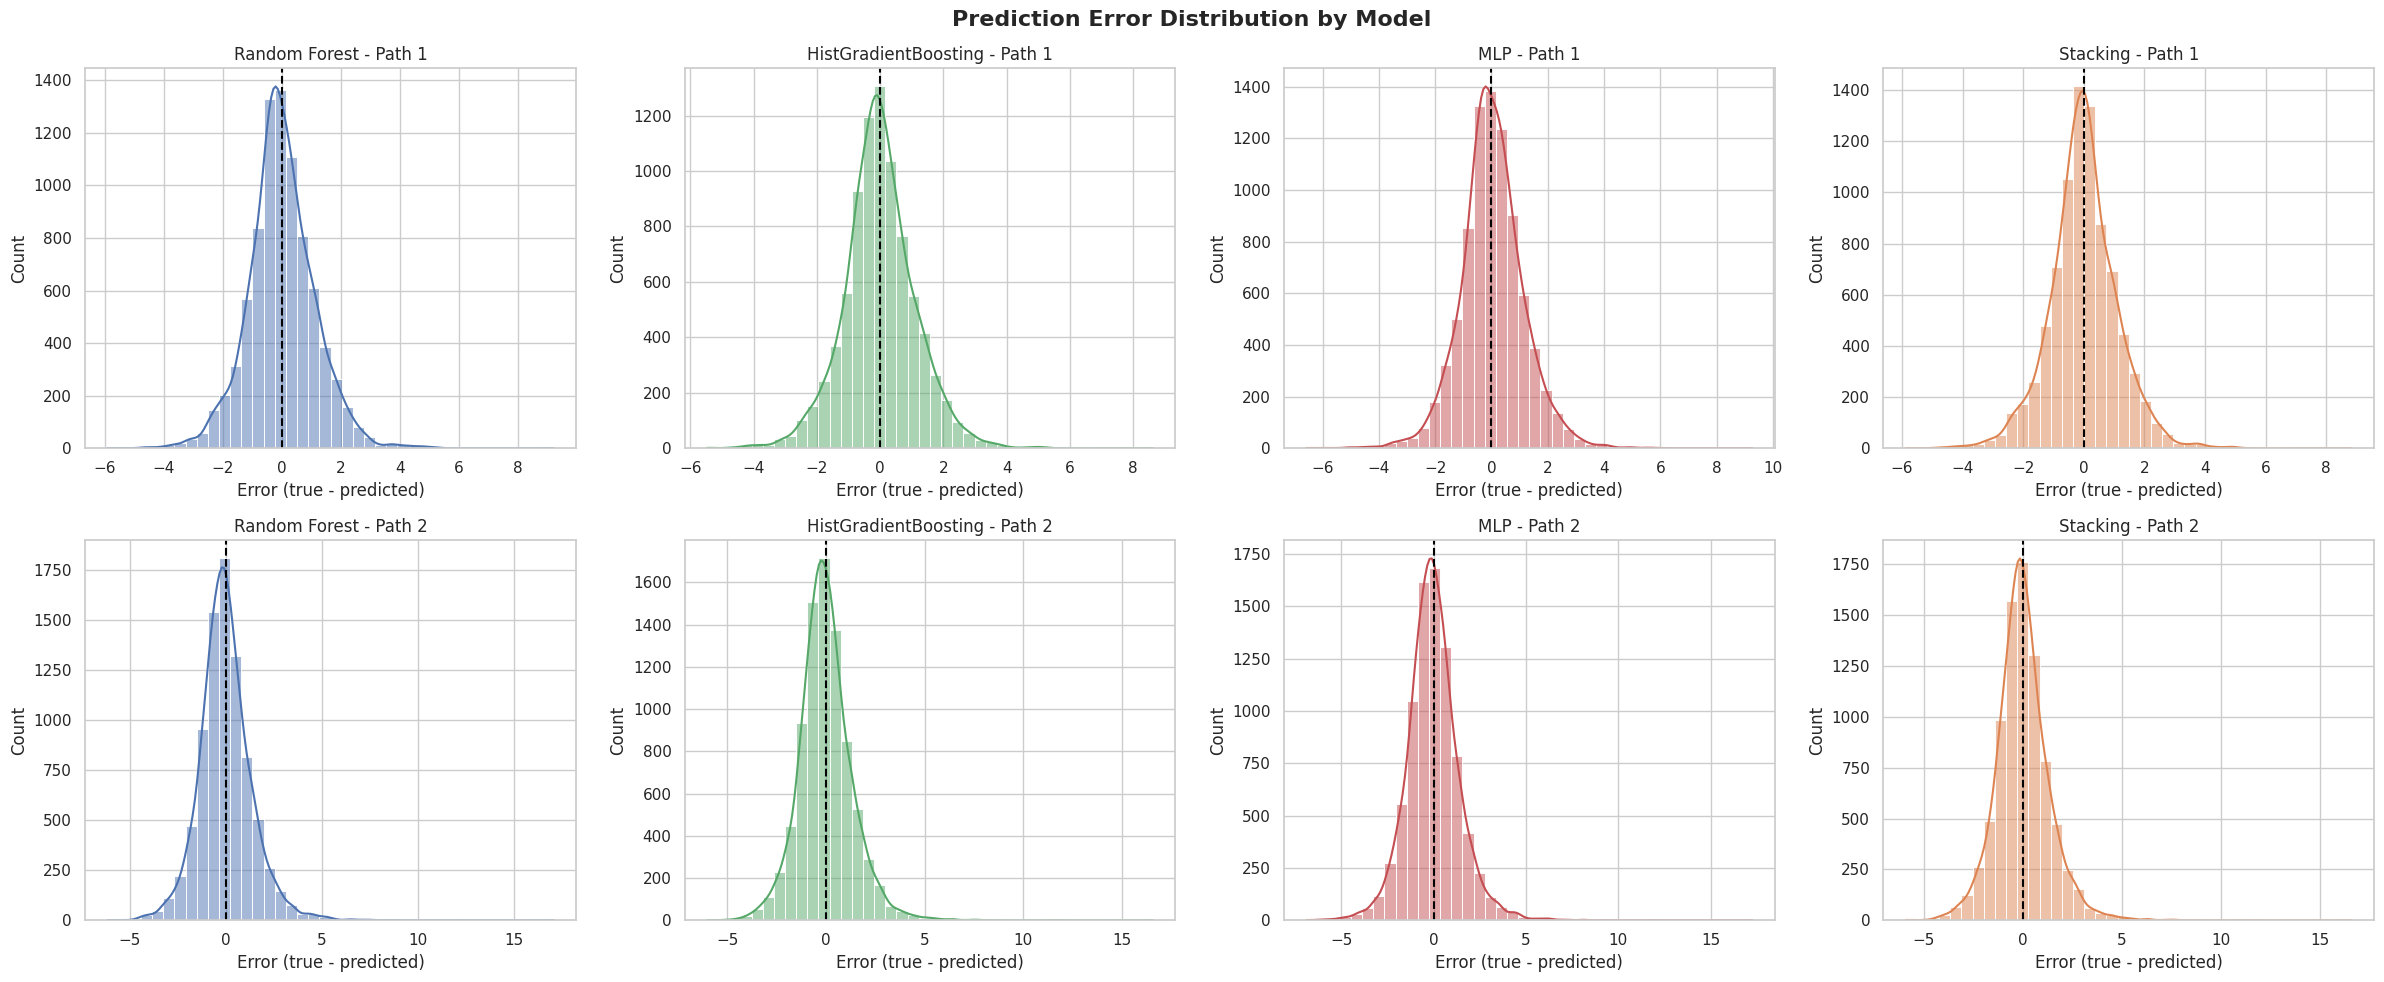

In [31]:
error_sets = [
    ('Random Forest', rf_res_p1, rf_res_p2, '#4C72B0'),
    ('HistGradientBoosting', hgb_res_p1, hgb_res_p2, '#55A868'),
    ('MLP', mlp_res_p1, mlp_res_p2, '#C44E52'),
    ('Stacking', stack_res_p1, stack_res_p2, '#DD8452'),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=False, sharey=False)
fig.suptitle('Prediction Error Distribution by Model', fontsize=16, fontweight='bold')

for idx, (model_name, err_p1, err_p2, color) in enumerate(error_sets):
    sns.histplot(err_p1, bins=40, kde=True, ax=axes[0, idx], color=color)
    axes[0, idx].axvline(0, color='black', linestyle='--', lw=1.5)
    axes[0, idx].set_title(f'{model_name} - Path 1')
    axes[0, idx].set_xlabel('Error (true - predicted)')
    axes[0, idx].set_ylabel('Count')

    sns.histplot(err_p2, bins=40, kde=True, ax=axes[1, idx], color=color)
    axes[1, idx].axvline(0, color='black', linestyle='--', lw=1.5)
    axes[1, idx].set_title(f'{model_name} - Path 2')
    axes[1, idx].set_xlabel('Error (true - predicted)')
    axes[1, idx].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Analytical Summary of Diagnostics

The residual plots and error distributions reveal complementary strengths across the four models. **HistGradientBoosting** and the **Stacking ensemble** (RF + HGB → Ridge) tend to produce the tightest error clustering around zero. The stacking model leverages both base learners' strengths via a Ridge meta-regressor trained on out-of-fold predictions, and its cross-validation stability should be compared directly against HGB using the bar charts above. Models with narrower CV error bars and lower RMSE/MAE are preferred for safety-critical localization where outlier errors are highly undesirable.

## 6. Model Choice

Having evaluated all four models, the best-performing regressor, Stacking ensemble, is serialized for deployment in the end-to-end inference pipeline.